## **Theoretical Questions**

Q1. What is Simple Linear Regression?

Ans. Simple Linear Regression is a statistical method used to study the relationship between one independent variable (X) and one dependent variable (Y). It fits a straight line equation to predict Y from X.

Q2. What are the key assumptions of Simple Linear Regression?

Ans. The key assumptions of Simple Linear Regression are:

Linearity – The relationship between the independent variable (X) and dependent variable (Y) is linear.

Independence – The observations (data points) are independent of each other.

Homoscedasticity – The variance of the errors (residuals) is constant for all values of X.

Normality – The residuals (errors) are normally distributed.

No significant outliers – The data should not contain extreme values that strongly influence the regression line.

Q3. What is heteroscedasticity, and why is it important to address in regression
models?

Ans. Heteroscedasticity occurs when the variance of the residuals (errors) is not constant across all values of the independent variable in a regression model. It is important to address because heteroscedasticity can lead to unreliable standard errors, incorrect hypothesis tests, and inaccurate confidence intervals, which reduces the validity of the regression results.

Q4. What is Multiple Linear Regression?

Ans. Multiple Linear Regression is a statistical method used to examine the relationship between one dependent variable and two or more independent variables.

It predicts the dependent variable using multiple predictors with the equation:

𝑌 = 𝑎 + 𝑏1𝑋1 + 𝑏2𝑋2 + ... + 𝑏𝑛𝑋𝑛


Q5. What is polynomial regression, and how does it differ from linear
regression?

Ans. Polynomial Regression is a type of regression used to model non-linear relationships between the independent variable and dependent variable by using higher-order terms. Unlike linear regression, which fits a straight line, polynomial regression fits a curved line to better represent complex relationships in the data.

Q6. Implement a Python program to fit a Simple Linear Regression model to
the following sample data:
● X = [1, 2, 3, 4, 5]

● Y = [2.1, 4.3, 6.1, 7.9, 10.2]

Plot the regression line over the data points.

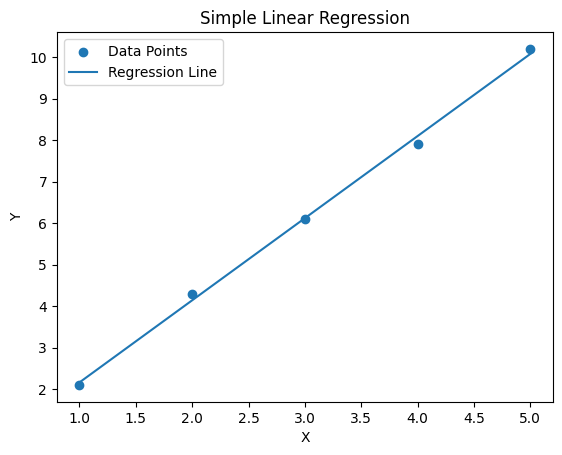

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# Create and fit the model
model = LinearRegression()
model.fit(X, Y)

# Predict values
Y_pred = model.predict(X)

# Plot data points
plt.scatter(X, Y, label="Data Points")

# Plot regression line
plt.plot(X, Y_pred, label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

Q7. Fit a Multiple Linear Regression model on this sample data:

● Area = [1200, 1500, 1800, 2000]

● Rooms = [2, 3, 3, 4]

● Price = [250000, 300000, 320000, 370000]

Check for multicollinearity using VIF and report the results.

In [3]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Sample data
data = {
    "Area": [1200, 1500, 1800, 2000],
    "Rooms": [2, 3, 3, 4],
    "Price": [250000, 300000, 320000, 370000]
}

df = pd.DataFrame(data)

# Independent variables
X = df[["Area", "Rooms"]]

# Dependent variable
y = df["Price"]

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit Multiple Linear Regression model
model = sm.OLS(y, X_const).fit()

print(model.summary())

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

print("\nVIF Values:")
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     351.0
Date:                Tue, 10 Mar 2026   Prob (F-statistic):             0.0377
Time:                        10:43:18   Log-Likelihood:                -35.242
No. Observations:                   4   AIC:                             76.48
Df Residuals:                       1   BIC:                             74.64
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.032e+05   9488.293     10.872      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Q8. Implement polynomial regression on the following data:

● X = [1, 2, 3, 4, 5]

● Y = [2.2, 4.8, 7.5, 11.2, 14.7]

Fit a 2nd-degree polynomial and plot the resulting curve.

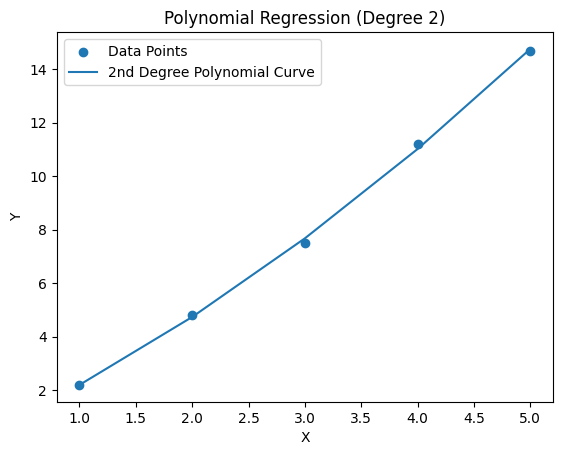

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Sample data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

# Convert to polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Train the model
model = LinearRegression()
model.fit(X_poly, Y)

# Predict values
Y_pred = model.predict(X_poly)

# Plot data points
plt.scatter(X, Y, label="Data Points")
# Plot polynomial regression curve
plt.plot(X, Y_pred, label="2nd Degree Polynomial Curve")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression (Degree 2)")
plt.legend()
plt.show()

Q9. Create a residuals plot for a regression model trained on this data:

● X = [10, 20, 30, 40, 50]

● Y = [15, 35, 40, 50, 65]

Assess heteroscedasticity by examining the spread of residuals.

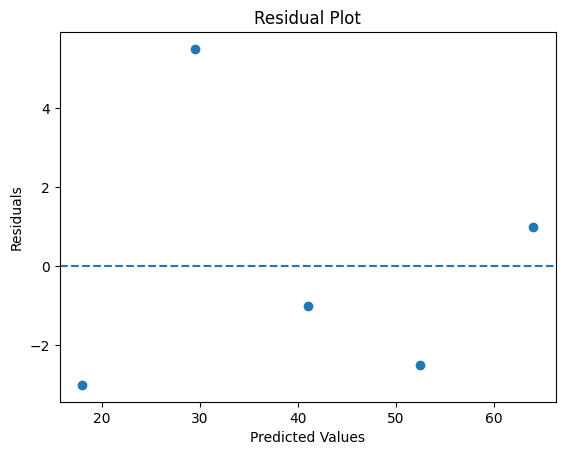

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([15, 35, 40, 50, 65])

# Train regression model
model = LinearRegression()
model.fit(X, Y)

# Predictions
Y_pred = model.predict(X)

# Residuals
residuals = Y - Y_pred

# Residual plot
plt.scatter(Y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Q10. Imagine you are a data scientist working for a real estate company. You
need to predict house prices using features like area, number of rooms, and location. However, you detect heteroscedasticity and multicollinearity in your regression model. Explain the steps you would take to address these issues and ensure a robust model.

Ans. As a data scientist, I would take the following steps to handle heteroscedasticity and multicollinearity and build a robust house price prediction model:

1. Detect the Problems

*   Use residual plots or Breusch–Pagan test to detect heteroscedasticity.
*   Use Variance Inflation Factor (VIF) to identify multicollinearity among predictors (area, rooms, location features).

2. Fix Heteroscedasticity

*   Apply log or square-root transformation to the target variable (e.g., log(price)).
*   Use Weighted Least Squares (WLS) or robust standard errors to stabilize variance.
*   Check residual plots again to confirm improvement.

3. Fix Multicollinearity

*   Remove or combine highly correlated variables.
*   Use feature selection techniques or Principal Component Analysis (PCA).
*   Apply regularization methods such as Ridge or Lasso regression.

4. Validate the Model

*   Split data into training and testing sets or use cross-validation.
*   Evaluate using metrics like R², RMSE, and MAE.